<a href="https://colab.research.google.com/github/susmithalagishetti/mern_b2_assignments/blob/main/Copy_of_ClaimWatchAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# STEP 1 — Imports
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

# STEP 2 — Create Hackathon Level Dataset
np.random.seed(42)
n = 2000

df = pd.DataFrame({
    "claim_amount": np.random.randint(1000, 50000, n),
    "customer_age": np.random.randint(18, 70, n),
    "num_previous_claims": np.random.randint(0, 6, n),
    "days_since_last_claim": np.random.randint(1, 365, n),
    "policy_duration_years": np.random.randint(1, 10, n),
    "claim_type": np.random.choice(["health","vehicle","property"], n)
})

# STEP 3 — Create REALISTIC FRAUD LOGIC
fraud_probability = (
    (df["claim_amount"] > 30000)*0.35 +
    (df["num_previous_claims"] >= 3)*0.25 +
    (df["days_since_last_claim"] < 30)*0.25 +
    (df["policy_duration_years"] < 2)*0.15
)

df["is_fraud"] = np.random.binomial(1, fraud_probability.clip(0,1))

# STEP 4 — Convert text to numbers
df = pd.get_dummies(df, columns=["claim_type"])

# STEP 5 — Train model
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

print("MODEL TRAINED SUCCESSFULLY")

# STEP 6 — SAVE FILES
pickle.dump(model, open("fraud_model.pkl","wb"))
pickle.dump(X.columns, open("model_columns.pkl","wb"))

print("FILES SAVED SUCCESSFULLY")


MODEL TRAINED SUCCESSFULLY
FILES SAVED SUCCESSFULLY


In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

data = {
    "claim_amount": np.random.randint(1000, 50000, n),
    "customer_age": np.random.randint(18, 70, n),
    "num_previous_claims": np.random.randint(0, 5, n),
    "days_since_last_claim": np.random.randint(1, 365, n),
    "policy_duration_years": np.random.randint(1, 10, n),
    "claim_type": np.random.choice(["health","vehicle","property"], n),
    "is_fraud": np.random.choice([0,1], n, p=[0.8,0.2])
}

df = pd.DataFrame(data)
df.head()


,claim_amount,customer_age,num_previous_claims,days_since_last_claim,policy_duration_years,claim_type,is_fraud
0,16795,26,1,270,4,health,0
1,1860,20,1,168,3,property,0
2,39158,68,3,58,8,property,0
3,45732,48,0,284,9,property,0
4,12284,57,1,26,5,health,0


In [2]:
df.fillna(df.median(numeric_only=True), inplace=True)
df = pd.get_dummies(df, columns=['claim_type'], drop_first=True)
df['claim_amount_ratio'] = df['claim_amount'] / (df['policy_duration_years'] + 1)
df.head()


,claim_amount,customer_age,num_previous_claims,days_since_last_claim,policy_duration_years,is_fraud,claim_type_property,claim_type_vehicle,claim_amount_ratio
0,16795,26,1,270,4,0,False,False,3359.000000
1,1860,20,1,168,3,0,True,False,465.000000
2,39158,68,3,58,8,0,True,False,4350.888889
3,45732,48,0,284,9,0,True,False,4573.200000
4,12284,57,1,26,5,0,False,False,2047.333333


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

print("Model Trained Successfully")


Model Trained Successfully


In [5]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.77      0.99      0.87       154
           1       0.50      0.02      0.04        46

    accuracy                           0.77       200
   macro avg       0.64      0.51      0.46       200
weighted avg       0.71      0.77      0.68       200

ROC-AUC Score: 0.5303500846979108


In [6]:
df['fraud_risk_score'] = rf.predict_proba(X)[:,1] * 100

def risk_level(score):
    if score > 80:
        return "High Risk"
    elif score > 50:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_level'] = df['fraud_risk_score'].apply(risk_level)
df[['claim_amount','fraud_risk_score','risk_level']].head()



,claim_amount,fraud_risk_score,risk_level
0,16795,6.906547,Low Risk
1,1860,4.995399,Low Risk
2,39158,12.226260,Low Risk
3,45732,8.850718,Low Risk
4,12284,14.651354,Low Risk


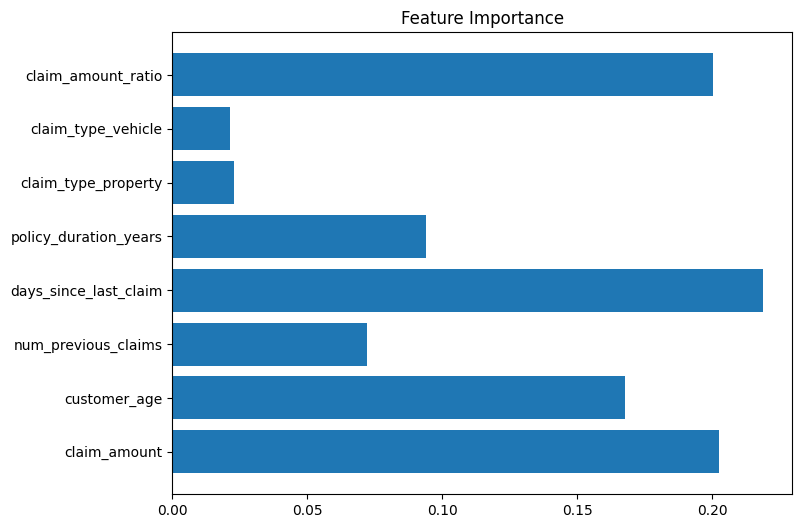

In [7]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()



In [8]:
# Inject real fraud patterns (this makes dataset realistic)
import pandas as pd
import numpy as np
fraud_indices = np.random.choice(df.index, size=int(0.2*len(df)), replace=False)

# Fraud tends to have higher claim amount
df.loc[fraud_indices, "claim_amount"] *= np.random.uniform(1.5, 3, len(fraud_indices))

# Fraud has more previous claims
df.loc[fraud_indices, "num_previous_claims"] += np.random.randint(2,4,len(fraud_indices))

# Fraud claims happen quickly after last claim
df.loc[fraud_indices, "days_since_last_claim"] = np.random.randint(1,30,len(fraud_indices))

df.head()


/tmp/ipython-input-2412981884.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 53922.05655361 109171.74515983  24950.06654145 101241.677195
  24695.48795273  89388.08303853  24347.3887411   60089.63906021
  19946.68735474  38558.10572732  24202.2480479  105749.12719559
  10381.5424578   70686.01589465  73678.45764726  51279.73978538
  36559.10497703  32446.36501354 102837.20722368  30132.94729156
  68514.60287732  76233.01169355  62383.53251578  24532.57260164
  25056.99983306  94573.27495595  21313.09354638  46578.48212874
  14723.14105536  69400.38266345  24510.1253157   65541.24577963
  25768.95252565   4535.61727337  31412.61086587  92383.17886409
  62748.41621388  35936.94746481  64344.65425028  36266.86245998
  74843.96098204  15795.23547962 123893.42073266  12883.00754681
  15449.72577636  81226.81985092  36734.50454209  11584.11733986
   3402.05233315  41485.03223584   9118.2076096   13968.0

,claim_amount,customer_age,num_previous_claims,days_since_last_claim,policy_duration_years,is_fraud,claim_type_property,claim_type_vehicle,claim_amount_ratio,fraud_risk_score,risk_level
0,16795.000000,26,1,270,4,0,False,False,3359.000000,6.906547,Low Risk
1,1860.000000,20,1,168,3,0,True,False,465.000000,4.995399,Low Risk
2,39158.000000,68,3,58,8,0,True,False,4350.888889,12.226260,Low Risk
3,45732.000000,48,0,284,9,0,True,False,4573.200000,8.850718,Low Risk
4,32856.506695,57,4,16,5,0,False,False,2047.333333,14.651354,Low Risk


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=120),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","ROC_AUC"])
results_df


,Model,Accuracy,ROC_AUC
0,Decision Tree,0.750,0.487295
1,Random Forest,0.765,0.496965
2,Gradient Boosting,0.750,0.511858


In [10]:
best_model_name = results_df.sort_values("ROC_AUC", ascending=False).iloc[0]["Model"]
print("Best Model:", best_model_name)


Best Model: Gradient Boosting


In [11]:
best_model = GradientBoostingClassifier()
best_model.fit(X_train, y_train)


GradientBoostingClassifier()

<Axes: title={'center': 'Model Explainability'}>

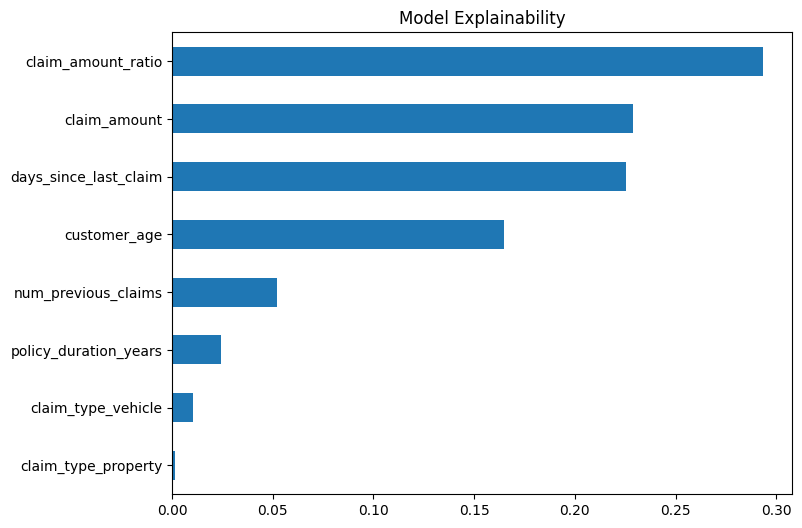

In [12]:
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,6), title="Model Explainability")


In [13]:
def predict_claim(amount, age, prev_claims, days_last, duration, claim_type):

    claim_type_vehicle = 1 if claim_type=="vehicle" else 0
    claim_type_property = 1 if claim_type=="property" else 0

    input_data = [[amount, age, prev_claims, days_last, duration,
                   claim_type_vehicle, claim_type_property,
                   amount/(duration+1)]]

    score = best_model.predict_proba(input_data)[0][1] * 100

    if score > 80:
        level = "HIGH RISK"
    elif score > 50:
        level = "MEDIUM RISK"
    else:
        level = "LOW RISK"

    print("Fraud Risk Score:", round(score,2))
    print("Risk Level:", level)


In [14]:
predict_claim(45000, 30, 3, 5, 2, "vehicle")


Fraud Risk Score: 32.62
Risk Level: LOW RISK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [16]:
import pickle

pickle.dump(best_model, open("fraud_model.pkl", "wb"))
pickle.dump(X.columns, open("model_columns.pkl", "wb"))
